# Titanic Survival Prediction using Logistic Regression

## Objective
To train a Logistic Regression model on the Titanic dataset
to predict whether a passenger survived or not.

## 1. Import Required Libraries

Import the necessary Python libraries for data handling,
model training, and model evaluation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Load the Dataset

Load the cleaned Titanic dataset and display the first few rows.

In [3]:
df = pd.read_csv("titanic_cleaned.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,0.0,1.0


## 3. Explore the Dataset

Check the shape and basic information of the dataset.


In [4]:
df.shape

(891, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked_C   891 non-null    float64
 11  Embarked_Q   891 non-null    float64
 12  Embarked_S   891 non-null    float64
dtypes: float64(5), int64(6), object(2)
memory usage: 90.6+ KB


## 4. Select Features and Target

Select the relevant features for prediction.
The target variable is Survived, which indicates whether
the passenger survived or not.

In [6]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
        'Embarked_C', 'Embarked_Q', 'Embarked_S']]

y = df['Survived']

In [7]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,3,1,35.0,0,0,8.0500,0.0,0.0,1.0


In [8]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## 5. Split the Dataset

Split the dataset into training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (712, 9)
Testing features: (179, 9)


## 6. Train Logistic Regression Model

Train a Logistic Regression model using the training data.

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 7. Make Predictions

Use the trained model to predict passenger survival
for the test data.

In [12]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

## 8. Evaluate Model Accuracy

Calculate the accuracy of the Logistic Regression model.

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8100558659217877
Accuracy (%): 81.00558659217877


## 9. Confusion Matrix

Display the confusion matrix to evaluate the classification
performance of the model.

In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [19 55]]


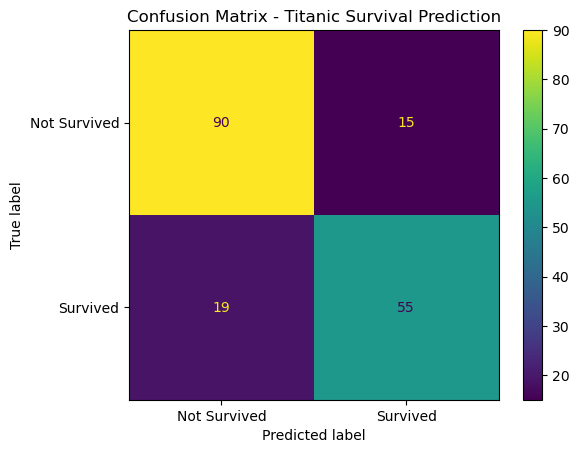

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Survived', 'Survived']
)

disp.plot()
plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.show()

## 10. Conclusion

The Logistic Regression model was successfully trained on
the Titanic dataset to predict passenger survival.

The model achieved an accuracy of 81.01% on the test dataset.
The confusion matrix was also used to evaluate the model's
classification performance.